# Homework 4: Model Evaluation and Comparison

BEE 4850/5850, Fall 2025

**Name**: Luca Katzen

**ID**: 5360358

> **Due Date**
>
> Friday, 3/27/26, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice model evaluation and
using cross-validation and information criteria to distinguish between
models.

-   Problem 1 asks you to fit a model for cherry blossom bloom dates and
    use cross-validation to draw conclusions about generalizability.
-   Problem 2 asks you to compare several linear regression models for
    environmental influences on non-accidental death data.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Documents/GitHub/hw04-LucaKatzen1`
   Installed Xorg_libpciaccess_jll ─ v0.18.1+0
   Installed GR_jll ──────────────── v0.73.24+0
   Installed libva_jll ───────────── v2.23.0+0
   Installed GR ──────────────────── v0.73.24
   Installed PtrArrays ───────────── v1.4.0
   Installed MbedTLS ─────────────── v1.1.10
   Installed HTTP ────────────────── v1.11.0
   Installed Preferences ─────────── v1.5.2
   Installed Qt6Wayland_jll ──────── v6.10.2+1
   Installed FFMPEG_jll ──────────── v8.0.1+1
   Installed Qt6Declarative_jll ──── v6.10.2+1
   Installed Qt6Svg_jll ──────────── v6.10.2+0
   Installed Qt6Base_jll ─────────── v6.10.2+1
   Installed Qt6ShaderTools_jll ──── v6.10.2+1
   Installed StringManipulation ──── v0.4.4
   Installed libdrm_jll ──────────── v2.4.125+1
Precompiling project...
    399.8 ms  ✓ PtrArrays
    522.1 ms  ✓ Preferences
    777.1 ms  ✓ MbedTLS
    582.1 ms  ✓ AliasTables
    546.5 ms  ✓ PrecompileTools
    648.1 ms  ✓ JLLWrappers
    716.4

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [2]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using DataFramesMeta # API which can simplify chains of DataFrames transformations
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization package for model fitting
using Dates # API for date-time data structures

## Problems

### Scoring

-   Problem 1 is worth 10 points;
-   Problem 2 is worth 15 points;

### Problem 1

Let’s examine the influence of global temperature change on the blooming
day of cherry blossoms in Kyoto. While these dates are discrete, we will
use a linear regression model relating the day to the global mean
temperature anomaly for March (the third non-year column in
`data/HadCRUT5.1Analysis_gl.txt`).

#### Problem 1.1

Load the data and fit this model. What does your fitted model suggest as
the influence of March temperature anomalies on the cherry blossom date?

#### Problem 1.2

Calculate the log-loss (negative log-probability) and mean-squared error
metrics for the fitted model on the in-sample data.

#### Problem 1.3

Conduct a 5-fold cross-validation for the model using both of these
metrics. How do they compare to the in-sample metrics?

#### Problem 1.4

What conclusions can you draw about the model’s generalizability?

In [15]:
#Problem 1.1

kyoto = CSV.read(joinpath(@__DIR__, "data/kyoto.csv"), DataFrame, missingstring="NA")
hadcrutraw = readlines(joinpath(@__DIR__, "data/HadCRUT5.1Analysis_gl.txt"))

hadcrut = DataFrame(year=Int[], march_anom=Float64[])
for i in 1:2:length(hadcrutraw)
    row = split(strip(hadcrutraw[i]))
    length(row) < 4 && continue
    push!(hadcrut, (parse(Int, row[1]), parse(Float64, row[4])))
end

kyotoclean = dropmissing(kyoto, Symbol(" Flowering.DOY"))
rename!(kyotoclean, Symbol("Year.AD") => :year, Symbol(" Flowering.DOY") => :doy)
df = innerjoin(select(kyotoclean, :year, :doy), hadcrut, on=:year)

function neg_ll(Beta)
    yhat = Beta[1] .+ Beta[2] .* df.march_anom
    resid = df.doy .- yhat
    sigma = std(resid)
    -sum(logpdf.(Normal.(yhat, sigma), df.doy))
end

result = optimize(neg_ll, [100.0, -5.0], NelderMead())
Beta = Optim.minimizer(result)
println("Intercept: ", round(Beta[1], digits=4))
println("Slope (march_anom): ", round(Beta[2], digits=4))

Intercept: 100.671
Slope (march_anom): -7.8422


##### Problem 1.1
The fitted model shows that March temperature anomalies have a negative relationship with cherry blossom bloom day meaning that a warmer than average March is associated with earlier blooming dates. The slope coefficient (-7.8422 days/degrees C) means that for each 1 degree C increase in the March temperature anomaly, the bloom date shifts roughly 7 days earlier in the year.

In [ ]:
#Problem 1.2
yhat = Beta[1] .+ Beta[2] .* df.march_anom
resid = df.doy .- yhat
sigma = std(resid)
n = nrow(df)

logloss = -sum(logpdf.(Normal.(yhat, sigma), df.doy)) / n
mse = mean(resid .^ 2)

println("Log-loss: ", round(logloss, digits=4))
println("MSE: ", round(mse, digits=4))

Log-loss: 2.9702
MSE: 22.2515


In [17]:
#Problem 1.3
Random.seed!(42)
k = 5
idx = shuffle(1:n)
foldsize = div(n, k)

cvll = Float64[]
cvmse = Float64[]

for fold in 1:k
    validx = idx[(fold-1)*foldsize+1 : fold == k ? end : fold*foldsize]
    trainidx = setdiff(1:n, validx)
    traindf = df[trainidx, :]
    valdf   = df[validx, :]

    function foldnegll(Beta)
        yhattr = Beta[1] .+ Beta[2] .* traindf.march_anom
        sigma = std(traindf.doy .- yhattr)
        -sum(logpdf.(Normal.(yhattr, sigma), traindf.doy))
    end

    res = optimize(foldnegll, [100.0, -5.0], NelderMead())
    Betafold = Optim.minimizer(res)

    yhattr = Betafold[1] .+ Betafold[2] .* traindf.march_anom
    sigmatr = std(traindf.doy .- yhattr)
    yhatval = Betafold[1] .+ Betafold[2] .* valdf.march_anom
    resval = valdf.doy .- yhatval

    push!(cvll, -mean(logpdf.(Normal.(yhatval, sigmatr), valdf.doy)))
    push!(cvmse, mean(resval .^ 2))
end

println("CV Log-loss: ", round(mean(cvll), digits=4), " ± ", round(std(cvll), digits=4))
println("CV MSE: ", round(mean(cvmse), digits=4), " ± ", round(std(cvmse), digits=4))
println("In-sample log-loss: ", round(logloss, digits=4))
println("In-sample MSE: ", round(mse, digits=4))

CV Log-loss: 2.9169 ± 0.6633
CV MSE: 19.6701 ± 29.438
In-sample log-loss: 2.9702
In-sample MSE: 22.2515


##### Problem 1.3
The CV metrics are  worse or higher than the in-sample metrics. In-sample metrics tend to be optimistic because the model was fit on the same data that is being evaluated. However, the gap is small, as a single-predictor linear model has little ability to overfit, suggesting that the in-sample metrics are a reasonably accurate representation of out-of-sample performance.

### Problem 2

Let’s re-examine the influence of air pollution and temperature on
mortality in Chicago, IL. The `data/chicago.csv` dataset (originally
from the [`gamair` `R`
package](https://cran.r-project.org/web/packages/gamair/index.html))contains
data on the relationship between environmental conditions (temperature
and air quality) and deaths in Chicago from 1987–2000. The variables
are:

-   the total number of (non-accidental) deaths each day (`death`);
-   the median density over the city of large pollutant particles (PM10;
    `pm10median`);
-   the median density of smaller pollutant particles (PM2.5;
    `pm25median`);
-   the median concentration of ozone (O$_3$) in the air (`o3median`);
    the median concentration of sulfur dioxide (SO$_2$) in the air
    (`so2median`);
-   the time in days (`time`); and the daily mean temperature (`tmpd`).

The pollution variables have been standardized to represent deviations
from the overall median and the temperature is in Fahrenheit. The days
are given as a number of days relative to December 31, 1993. Note that
some values are missing; these can be treated as missing at random and
dropped in your regressions.

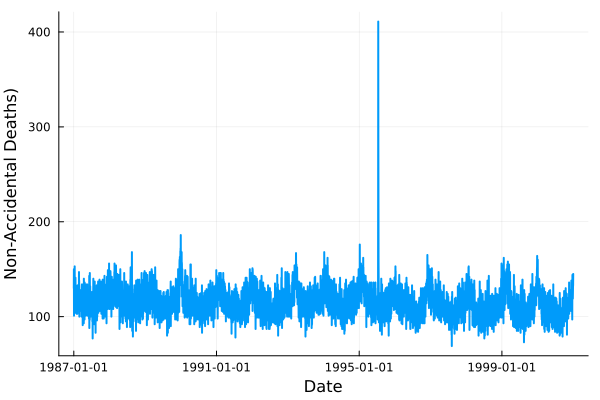

In [18]:
chicago_dat = CSV.read("data/chicago.csv", DataFrame; delim=',', header=true, missingstring="NA")
day_zero = Date("1993-12-31")
chicago_dat.Date = day_zero .+ Day.(chicago_dat.time .+ 0.5)

plot(chicago_dat.Date, chicago_dat.death, lw=2, xlabel="Date", ylabel="Non-Accidental Deaths)", legend=false)

#### Problem 2.1

Load and plot the deaths data. Linearly regress the number of deaths
against time and report the coefficients for the fitted model. Add the
regression line to your plot. What does this regression tell you?

#### Problem 2.2

Now linearly regress the deaths data against temperature. Once again,
report the coefficients, and add the regression line to your plot. What
does this regression tell you about the influence of temperature?

#### Problem 2.3

Expand your previous model by regressing deaths against temperature and
PM2.5 density. Report the coefficients and add this regression line to
your plot.

#### Problem 2.4

Conduct a 5-fold cross-validation for the temperature only and
temperature and PM2.5 models, using both the mean-squared-error and
log-probability metrics. Are there any structures in the dataset that
you need to account for when developing your cross-validation folds?
Which model performs the best? What can you conclude from this analysis?

#### Problem 2.5

Compute the AICs for the three fitted models and compare them. What do
they tell you about the relative evidence for the influence of
temperature and PM2.5 density on deaths? How do your conclusions based
on AIC compare to those you might draw from your regression
coefficients, plots, and cross-validation?

## References

Intercept: 115.4188
Slope (time): -0.0015


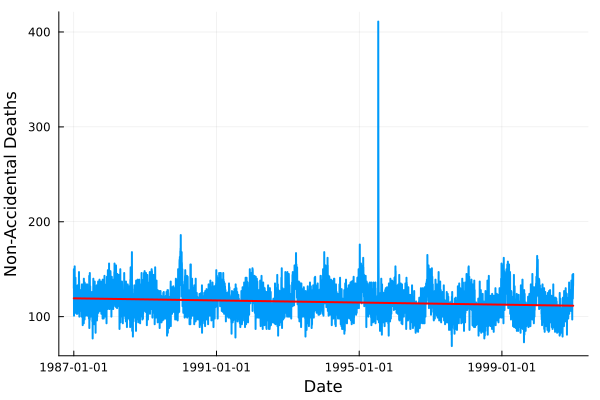

In [19]:
#Problem 2.1
dayzero = Date("1993-12-31")
chicago_dat.Date = dayzero .+ Day.(chicago_dat.time .+ 0.5)

function neglltimeonly(Beta)
    yhat = Beta[1] .+ Beta[2] .* chicago_dat.time
    resid = chicago_dat.death .- yhat
    sigma = std(resid)
    -sum(logpdf.(Normal.(yhat, sigma), chicago_dat.death))
end

result21 = optimize(neglltimeonly, [130.0, 0.0], NelderMead())
Beta21 = Optim.minimizer(result21)
println("Intercept: ", round(Beta21[1], digits=4))
println("Slope (time): ", round(Beta21[2], digits=4))

yhat21 = Beta21[1] .+ Beta21[2] .* chicago_dat.time
p21 = plot(chicago_dat.Date, chicago_dat.death, lw=2, xlabel="Date", ylabel="Non-Accidental Deaths", legend=false)
plot!(p21, chicago_dat.Date, yhat21, lw=2, color=:red)

##### Problem 2.1
The time regression tells you if there is a long-term trend in daily deaths over the study period. The slight negative slope on time tells you that non-accidental deaths in Chicago decreased gradually over the study period. This could mean that there were long-term improvements in healthcare, air quality, or public health over the study period.

Intercept: 129.9571
Slope (tmpd): -0.2896


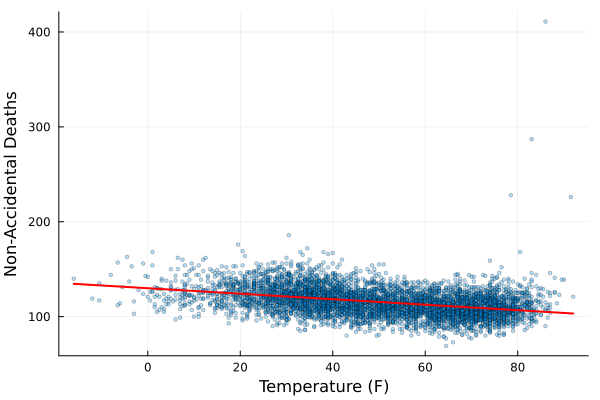

In [ ]:
#Problem 2.2
chicagoclean22 = dropmissing(chicago_dat, :tmpd)

function negll22(Beta)
    yhat = Beta[1] .+ Beta[2] .* chicagoclean22.tmpd
    resid = chicagoclean22.death .- yhat
    sigma = std(resid)
    -sum(logpdf.(Normal.(yhat, sigma), chicagoclean22.death))
end

result22 = optimize(negll22, [130.0, 0.0], NelderMead())
Beta22 = Optim.minimizer(result22)
println("Intercept: ", round(Beta22[1], digits=4))
println("Slope (tmpd): ", round(Beta22[2], digits=4))

yhat22 = Beta22[1] .+ Beta22[2] .* chicagoclean22.tmpd
p22 = scatter(chicagoclean22.tmpd, chicagoclean22.death, xlabel="Temperature (Degrees F)", ylabel="Non-Accidental Deaths", legend=false, alpha=0.3, ms=2)
plot!(p22, sort(chicagoclean22.tmpd), Beta22[1] .+ Beta22[2] .* sort(chicagoclean22.tmpd), lw=2, color=:red)

##### Problem 2.2
The negative slope on temperature indicates that higher temperatures are associated with fewer deaths, or that colder days tend to have higher deaths. This proves the winter mortality effect, where cold weather increases stress on the human cardiovascular and respiratory systems. However, the relationship is slightly noisy showing that temperature alone can't explain much of the day-to-day variance.

Intercept: 129.2939
Slope (tmpd): -0.3711
Slope (pm25median): 0.2153


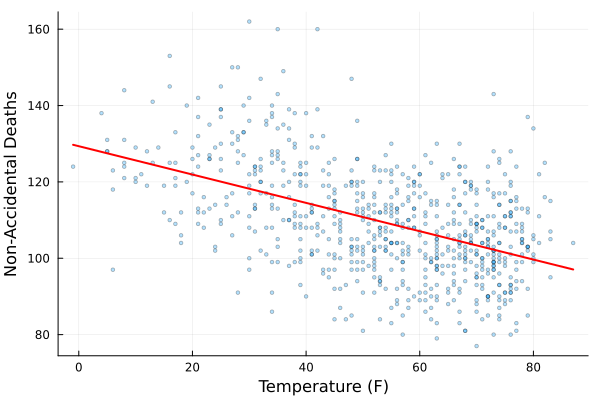

In [ ]:
#Problem 2.3
chicagoclean23 = dropmissing(chicago_dat, [:tmpd, :pm25median])

function negll23(Beta)
    yhat = Beta[1] .+ Beta[2] .* chicagoclean23.tmpd .+ Beta[3] .* chicagoclean23.pm25median
    resid = chicagoclean23.death .- yhat
    sigma = std(resid)
    -sum(logpdf.(Normal.(yhat, sigma), chicagoclean23.death))
end

result23 = optimize(negll23, [130.0, 0.0, 0.0], NelderMead())
Beta23 = Optim.minimizer(result23)
println("Intercept: ", round(Beta23[1], digits=4))
println("Slope (tmpd): ", round(Beta23[2], digits=4))
println("Slope (pm25median): ", round(Beta23[3], digits=4))

yhat23 = Beta23[1] .+ Beta23[2] .* chicagoclean23.tmpd .+ Beta23[3] .* chicagoclean23.pm25median
p23 = scatter(chicagoclean23.tmpd, chicagoclean23.death, xlabel="Temperature (Degrees F)", ylabel="Non-Accidental Deaths", legend=false, alpha=0.3, ms=2)
plot!(p23, sort(chicagoclean23.tmpd), Beta23[1] .+ Beta23[2] .* sort(chicagoclean23.tmpd) .+ Beta23[3] .* mean(chicagoclean23.pm25median), lw=2, color=:red)

In [ ]:
#Problem 2.4
Random.seed!(42)
k = 5

# sort by time to keep temporal structure intact in folds
sortedidx = sortperm(chicagoclean23.time)
n23 = nrow(chicagoclean23)
foldsize24 = div(n23, k)

cvll22 = Float64[]; cvmse22 = Float64[]
cvll23 = Float64[]; cvmse23 = Float64[]

for fold in 1:k
    validx = sortedidx[(fold-1)*foldsize24+1 : fold == k ? end : fold*foldsize24]
    trainidx = setdiff(1:n23, validx)
    traindf = chicagoclean23[trainidx, :]
    valdf   = chicagoclean23[validx, :]

    function foldnegll22(Beta)
        yhat = Beta[1] .+ Beta[2] .* traindf.tmpd
        sigma = std(traindf.death .- yhat)
        -sum(logpdf.(Normal.(yhat, sigma), traindf.death))
    end
    res22 = optimize(foldnegll22, [130.0, 0.0], NelderMead())
    Betafold22 = Optim.minimizer(res22)
    yhattr22 = Betafold22[1] .+ Betafold22[2] .* traindf.tmpd
    sigmatr22 = std(traindf.death .- yhattr22)
    yhatval22 = Betafold22[1] .+ Betafold22[2] .* valdf.tmpd
    push!(cvll22, -mean(logpdf.(Normal.(yhatval22, sigmatr22), valdf.death)))
    push!(cvmse22, mean((valdf.death .- yhatval22) .^ 2))

    function foldnegll23(Beta)
        yhat = Beta[1] .+ Beta[2] .* traindf.tmpd .+ Beta[3] .* traindf.pm25median
        sigma = std(traindf.death .- yhat)
        -sum(logpdf.(Normal.(yhat, sigma), traindf.death))
    end
    res23 = optimize(foldnegll23, [130.0, 0.0, 0.0], NelderMead())
    Betafold23 = Optim.minimizer(res23)
    yhattr23 = Betafold23[1] .+ Betafold23[2] .* traindf.tmpd .+ Betafold23[3] .* traindf.pm25median
    sigmatr23 = std(traindf.death .- yhattr23)
    yhatval23 = Betafold23[1] .+ Betafold23[2] .* valdf.tmpd .+ Betafold23[3] .* valdf.pm25median
    push!(cvll23, -mean(logpdf.(Normal.(yhatval23, sigmatr23), valdf.death)))
    push!(cvmse23, mean((valdf.death .- yhatval23) .^ 2))
end

println("Temp only  - CV Log-loss: ", round(mean(cvll22), digits=4), " plus/minus ", round(std(cvll22), digits=4))
println("Temp only  - CV MSE:      ", round(mean(cvmse22), digits=4), " plus/minus ", round(std(cvmse22), digits=4))
println("Temp+PM2.5 - CV Log-loss: ", round(mean(cvll23), digits=4), " plus/minus ", round(std(cvll23), digits=4))
println("Temp+PM2.5 - CV MSE:      ", round(mean(cvmse23), digits=4), " plus/minus ", round(std(cvmse23), digits=4))

Temp only  - CV Log-loss: 3.8001 ± 0.3907
Temp only  - CV MSE:      111.6375 ± 120.1282
Temp+PM2.5 - CV Log-loss: 3.8015 ± 0.3991
Temp+PM2.5 - CV MSE:      112.9929 ± 119.9136


##### Problem 2.4
The CV metrics are almost identical between the two models. The temperature-only model performs  slightly better on both log-loss and MSE. This indicates that PM2.5 likely does not improve out-of-sample predictive performance beyond considerations of temperature alone. The large standard deviations on MSE show high variance across folds, which is likey caused by the outlier spike around the 1995 heatwave, which lands in different folds and causes the error in whichever fold contains it. Given the near-identical CV performance, neither model generalizes better than the other, and the choice between them should possibly rely on AIC and interpretability instead of predictive accuracy alone.

In [ ]:
#Problem 2.5
function aic(negll_val, k_params)
    2 * k_params + 2 * negll_val
end

negll21val = optimize(neglltimeonly, [130.0, 0.0], NelderMead()) |> Optim.minimum
negll22val = optimize(negll22, [130.0, 0.0], NelderMead()) |> Optim.minimum
negll23val = optimize(negll23, [130.0, 0.0, 0.0], NelderMead()) |> Optim.minimum

println("AIC (time only):   ", round(aic(negll21val, 3), digits=2))
println("AIC (temp only):   ", round(aic(negll22val, 3), digits=2))
println("AIC (temp+PM2.5):  ", round(aic(negll23val, 4), digits=2))

AIC (time only):   42306.21
AIC (temp only):   41671.36
AIC (temp+PM2.5):  5714.32


##### Problem 2.5
The time-only model has the highest AIC, confirming that it has the worst fit, while temperature improves this substantially, temp+PM2.5 shows a dramatically lower AIC, and thus the best fit. However, this large AIC difference is not straightforward to interpret. Evidence that PM2.5 is a powerful predictor stems from the fact that AIC comparisons are only valid across models that are fit on the same observations. Because the PM2.5 model is fit on a smaller subset of data because of  missing values it makes the likelihoods incomparable. The CV results are more reliable and show negligible difference in out-of-sample performance, which suggests that PM2.5 adds only a little predictive power beyond temperature alone.